In [1]:
import dowhy
from dowhy import CausalModel
from dowhy.causal_refuters.placebo_treatment_refuter import PlaceboType
import dowhy.causal_refuters.bootstrap_refuter
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
dowhy.__version__ # v0.12

'0.12'

In [3]:
# Function to simulate data with continuous treatment and multiple outcomes
def simulate_data_continuous_multiple_outcomes(sample_size=100000):
    np.random.seed(2)
    
    # Unobserved confounder: diet
    diet = np.random.normal(0, 1, sample_size)

    # Exercise
    exercise = 1.7 * diet + np.random.normal(0, 1, sample_size) # Treatment
    # CaloricBurn
    caloric_burn = 1.5 * exercise + np.random.normal(0, 1, sample_size) # Mediator
    # WeightLoss
    weightloss = 1.3 * caloric_burn + 1.1 * diet + np.random.normal(0, 1, sample_size) # Outcome
     
    data = pd.DataFrame({
        'Exercise': exercise, 
        'CaloricBurn': caloric_burn, 
        'Weightloss': weightloss,
    })
    
    return data

# Create data
data = simulate_data_continuous_multiple_outcomes()

# Display the first few rows of the data
print(data.head())

   Exercise  CaloricBurn  Weightloss
0 -0.996095    -1.467706   -1.817333
1 -1.421488    -1.640321   -1.571441
2 -4.599223    -5.636960  -10.413511
3  4.447812     6.814439   10.326459
4 -3.335910    -5.529117   -8.564030


In [4]:
# Create a custom graph with an unobserved confounder 'U'
causal_graph = """
digraph {
    Diet_U[label="Diet (unobserved)", style=dotted]
    Exercise -> CaloricBurn;
    CaloricBurn -> Weightloss;
    Diet_U -> Exercise;
    Diet_U -> Weightloss;
}
"""

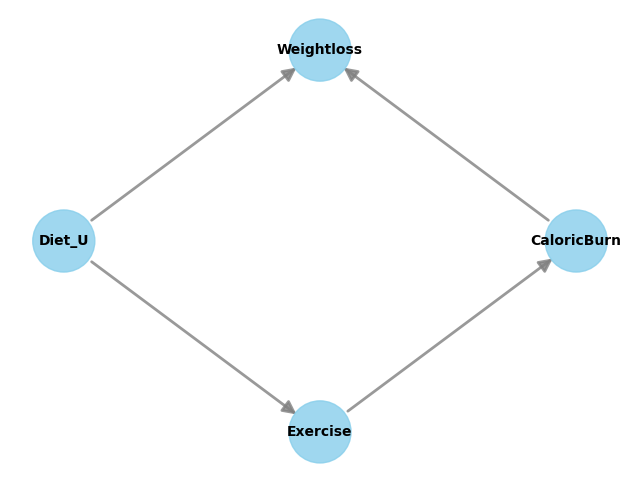

In [5]:
# Define a CausalModel object in DoWhy, indicate treatment & outcome
model= CausalModel(
    data=data, # data columns
    treatment="Exercise", # cause of interest, X
    outcome="Weightloss", # outcome, Y
    graph=causal_graph,
    frontdoor_variables=["CaloricBurn"],
    )
model.view_model()

In [6]:
# Identify causal effect
identified_estimand = model.identify_effect()
print("Frontdoor variables:")
for fv in sorted(identified_estimand.get_frontdoor_variables()):
    print(fv)

Frontdoor variables:
CaloricBurn


In [7]:
# Estimate causal effect using linear regression
estimate = model.estimate_effect(identified_estimand,
                                 method_name="frontdoor.linear_regression")

# Print results
print(estimate)
estimate.interpret()

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: frontdoor
Estimand expression:
 ⎡      d                         d                    ⎤
E⎢──────────────(Weightloss)⋅───────────([CaloricBurn])⎥
 ⎣d[CaloricBurn]             d[Exercise]               ⎦
Estimand assumption 1, Full-mediation: CaloricBurn intercepts (blocks) all directed paths from Exercise to W,e,i,g,h,t,l,o,s,s.
Estimand assumption 2, First-stage-unconfoundedness: If U→{Exercise} and U→{CaloricBurn} then P(CaloricBurn|Exercise,U) = P(CaloricBurn|Exercise)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{CaloricBurn} and U→Weightloss then P(Weightloss|CaloricBurn, Exercise, U) = P(Weightloss|CaloricBurn, Exercise)

## Realized estimand
b: Weightloss~Exercise
Target units: ate

## Estimate
Mean value: 2.4325304015421523

Increasing the treatment variable(s) [Exercise] from 0 to 1 causes an increase of 2.4325304015421523 in the expected 

In [8]:
# Refute the estimate - Placebo Treatment
# What happens to the estimated causal effect when we replace the true treatment variable with an independent permutated treatment variable?
# If our assumptions were correct then this newly found estimate should go to 0.
refutation = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="placebo_treatment_refuter", 
    random_seed=13, 
    placebo_type = dowhy.causal_refuters.placebo_treatment_refuter.PlaceboType.PERMUTE
    )
print(refutation)

# Null hypothesis is that the placebo treatment has an effect on the outcome.
# p_value = 0.88 indicating that the null hypothesis can be rejected. Placebo treatment effect is statistically insignificant, suggesting that the model behaves as expected when the treatment is replaced with a placebo.

Refute: Use a Placebo Treatment
Estimated effect:2.4325304015421523
New effect:-0.000995167827401897
p value:0.88



In [9]:
# Refute the estimate - Dummy Outcome Effect
# Does the estimated causal effect change when we replace the true outcome variable with an independent random variable?
# If our assumption was originally correct then the causal estimate shouldn't change by much.
refutation = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="dummy_outcome_refuter",
    random_seed=13
    )
print(refutation[0])

# Null hypothesis is that the effect size is significantly different after adding the dummy outcome.
# p_value = 0.92 indicating the the null hypotheis can be rejected. The new effect is statistically indistinguishable from the original effect.

Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.00020089428077294736
p value:0.92



In [10]:
# Refute the estimate - Data subsample
# Does the estimated effect change significantly when we replace the given dataset with a randomly selected subset?
# If our assumption was originally correct then the causal estimate shouldn't change by much.
refutation = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="data_subset_refuter",
    random_seed=13
    )
print(refutation)

# Null hypothesis is that the new effect size (from the subset) is significantly different from the original effect size (from the full dataset).
# p_value = 0.88 indicating that the null hypothesis can be rejected. The difference between the original and subset-based effect estimates is not statistically significant.

Refute: Use a subset of data
Estimated effect:2.4325304015421523
New effect:2.4326475742902143
p value:0.8799999999999999



In [11]:
# Refute the estimate - Bootstrap
# Does the estimated effect change significantly when we replace the given dataset with bootstrapped samples from the same dataset?
# If our assumption was originally correct then the causal estimate shouldn't change by much.
refutation = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="bootstrap_refuter", 
    required_variables=False,
    random_seed=13
    )
print(refutation)

# Null hypothesis that there is a significant difference between the original treatment effect and the new effect from bootstrap sampling.
# p_value = 0.94 indicating that the null hypothesis can be rejected. This confirms that The difference between the original and bootstrap-based effect is not statistically significant.

Refute: Bootstrap Sample Dataset
Estimated effect:2.4325304015421523
New effect:2.4321415564822133
p value:0.94

